In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20
    
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
sheet_names = ['MLR', 'DT', 'RF', 'KNN', 'SVM']
x_ticks = ['MLR train', 'MLR test', 'DT train', 'DT test', 'RF train', 'RF test', 'KNN train', 'KNN test', 'SVM train', 'SVM test']
random_states = [15, 28, 42]

In [3]:
def prepare_histogram_data(target_name, max_number_of_features):
    
    excel_files = []
    
    for name in glob.glob('../Data/Quality_'+str(target_name)+'*'):
        excel_files.append(name)
        
    random_state_15 = []
    random_state_28 = []
    random_state_42 = []
    features_15 = []
    features_28 = []
    features_42 = []
    random_states = [15, 28, 42]
    
    for random_state in range(len(random_states)):
        tmp = []
        to_plot = []
        values = []
        number_of_features = []
        for sheet in sheet_names:
            tmp.append(pd.read_excel(excel_files[random_state], sheet_name=sheet))
        for data in tmp:
            temp = data[data['Number of features'] <= max_number_of_features]
            temp_ = temp.copy()
            # Filter rows where Training RMSE is lower than Test RMSE
            temp = temp[temp['Training Accuracy'] > temp['Test Accuracy']]
            # Filter rows where Training R^2 score is higher than Test R^2
            temp = temp[temp['Training Precision'] > temp['Test Precision']]
            if not temp.empty:
                to_plot.append(temp[temp['Test Precision'] == min(temp['Test Precision'])])
            else:
                to_plot.append(temp_[temp_['Test Precision'] == min(temp_['Test Precision'])])
        for value in to_plot:
            values.append(value['Training Accuracy'].tail(1))
            values.append(value['Test Accuracy'].tail(1))
            number_of_features.append(value['Number of features'].tail(1))
            #values.append(value['Training RMSE'].head(1))
            #values.append(value['Test RMSE'].head(1))
            #number_of_features.append(value['Number of features'].head(1))
        for element in values:
            if random_state == 0:
                random_state_15.append(float(element))
            elif random_state == 1:
                random_state_28.append(float(element))                      
            elif random_state == 2:
                random_state_42.append(float(element))
            else:
                print("Error with conditions...")
                
        for features in number_of_features:
            if random_state == 0:
                features_15.append(float(features))
            elif random_state == 1:
                features_28.append(float(features))                      
            elif random_state == 2:
                features_42.append(float(features))
            else:
                print("Error with conditions...")
        
                
    return  random_state_15, random_state_28, random_state_42, features_15, features_28, features_42

In [4]:
def handle_negative_corr(list_):
    res = []
    for element in list_:
        if element < 0:
            res.append(0.01)
        else:
            res.append(np.sqrt(element))
    return res

In [5]:
def prepare_plot(data, name, max_number_of_features):

    fig = plt.figure(figsize=(20,10))
    X = x_ticks
    y_15 = data[0] #handle_negative_corr(data[0])
    y_28 = data[1] #handle_negative_corr(data[1])
    y_42 = data[2] #handle_negative_corr(data[2])

    X_axis = np.arange(len(X))
    #y_ax = [x/100 for x in range(0, 105, 5)]
    #plt.yticks(y_ax)
    plt.bar(X_axis - 0.2, y_15, 0.2, label = 'Random state 15')
    plt.bar(X_axis + 0.0, y_28, 0.2, label = 'Random state 28')
    plt.bar(X_axis + 0.2, y_42, 0.2, label = 'Random state 42')

    plt.xticks(X_axis, X, weight='bold', fontsize=14)
    plt.xlabel("Methodology", fontsize=20, weight='bold')
    plt.ylabel("Accuracy", fontsize=18, weight='bold')
    #plt.ylim([0.0, 1.0])
    plt.title("Quality of each methodology - "+str(name)+' '+str('max number of features: '+str(max_number_of_features)), fontsize=24, weight='bold')
    plt.grid(visible=True)
    plt.legend()
    plt.savefig('Figures/'+'_'+str(name)+'_'+str(max_number_of_features)+'_'+'.pdf', bbox_inches='tight') #new line
    plt.show()
    for i, state in enumerate(random_states):
        print('Random state - '+str(state)+' '+str(update_description(sheet_names, data[i+3])))

In [6]:
def update_description(x_axis_labels, number_of_features):
    
    MLR = str(x_axis_labels[0])+' - number of features used: '+str(number_of_features[0])
    DT = str(x_axis_labels[1])+' - number of features used: '+str(number_of_features[1])
    RF = str(x_axis_labels[2])+' - number of features used: '+str(number_of_features[2])
    KNN = str(x_axis_labels[3])+' - number of features used: '+str(number_of_features[3])
    SVM = str(x_axis_labels[4])+' - number of features used: '+str(number_of_features[4])
    
    return MLR, DT, RF, KNN, SVM
    

## EE

In [7]:
ee = prepare_histogram_data('epox_cla', 12)

C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_15.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_15.append(float(features))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_28.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_28.append(float(features)

In [8]:
ee

([0.7678571428571429,
  0.5454545454545454,
  1.0,
  0.4545454545454545,
  0.9642857142857143,
  0.5454545454545454,
  0.875,
  0.3636363636363636,
  0.5,
  0.2727272727272727],
 [0.8571428571428571,
  0.6363636363636364,
  1.0,
  0.4545454545454545,
  0.875,
  0.6363636363636364,
  0.8214285714285714,
  0.6363636363636364,
  0.9285714285714286,
  0.5454545454545454],
 [0.8571428571428571,
  0.6363636363636364,
  0.8928571428571429,
  0.5454545454545454,
  0.9821428571428571,
  0.6363636363636364,
  0.8214285714285714,
  0.5454545454545454,
  0.4821428571428572,
  0.3636363636363636],
 [5.0, 9.0, 8.0, 3.0, 3.0],
 [8.0, 3.0, 3.0, 3.0, 8.0],
 [9.0, 8.0, 5.0, 3.0, 3.0])

C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_15.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_15.append(float(features))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_28.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_28.append(float(features)

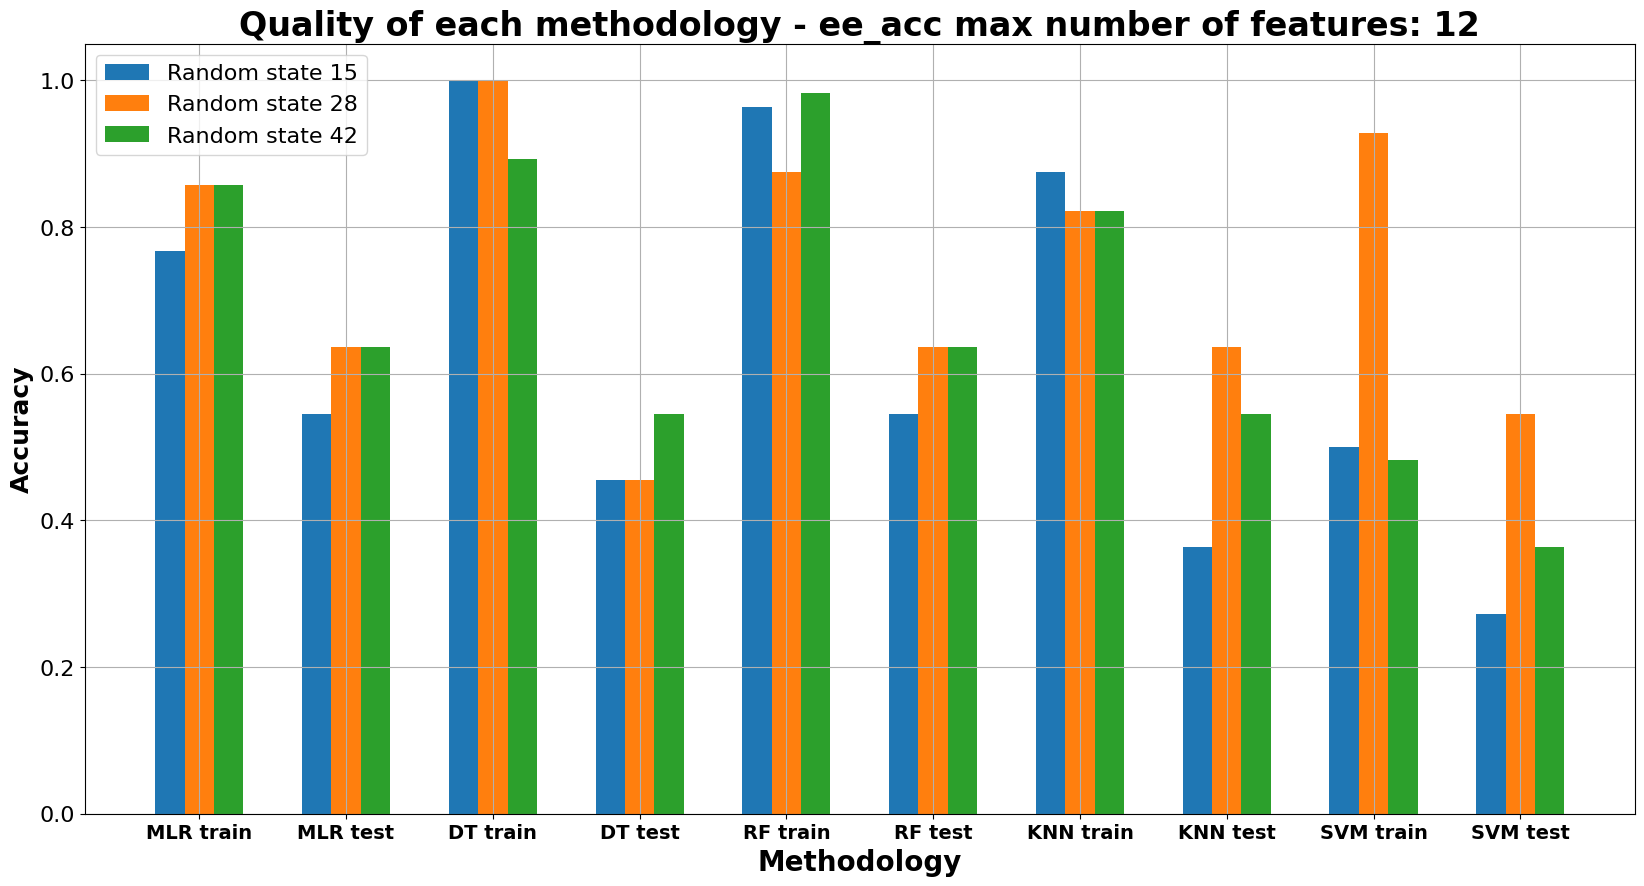

Random state - 15 ('MLR - number of features used: 5.0', 'DT - number of features used: 9.0', 'RF - number of features used: 8.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 28 ('MLR - number of features used: 8.0', 'DT - number of features used: 3.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 8.0')
Random state - 42 ('MLR - number of features used: 9.0', 'DT - number of features used: 8.0', 'RF - number of features used: 5.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')


C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_15.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_15.append(float(features))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_28.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_28.append(float(features)

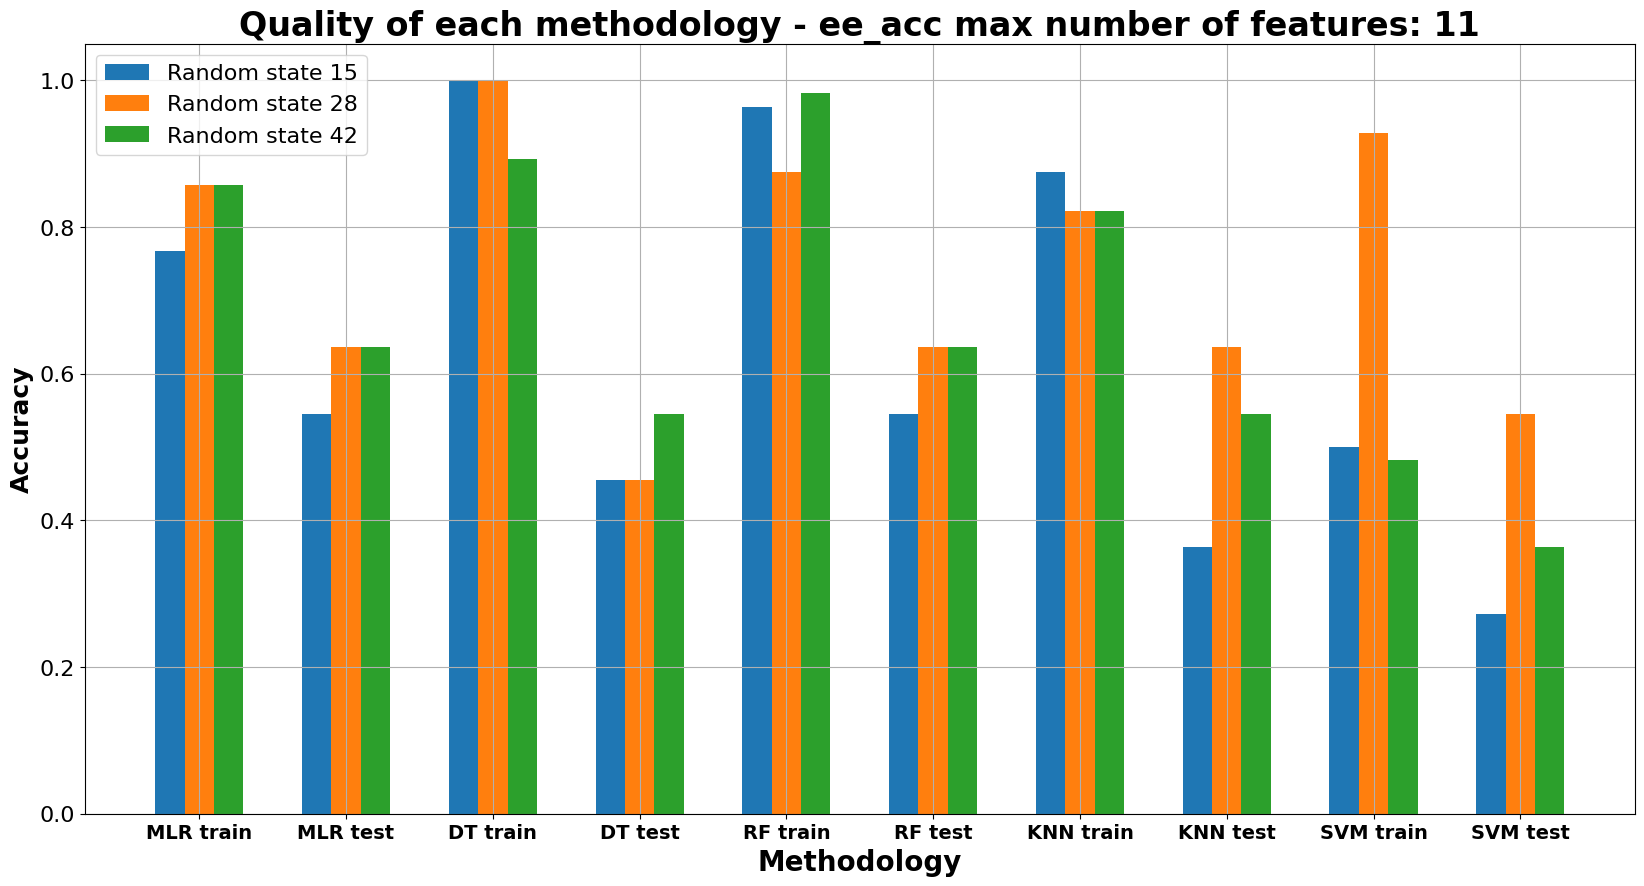

Random state - 15 ('MLR - number of features used: 5.0', 'DT - number of features used: 9.0', 'RF - number of features used: 8.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 28 ('MLR - number of features used: 8.0', 'DT - number of features used: 3.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 8.0')
Random state - 42 ('MLR - number of features used: 9.0', 'DT - number of features used: 8.0', 'RF - number of features used: 5.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')


C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_15.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_15.append(float(features))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_28.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_28.append(float(features)

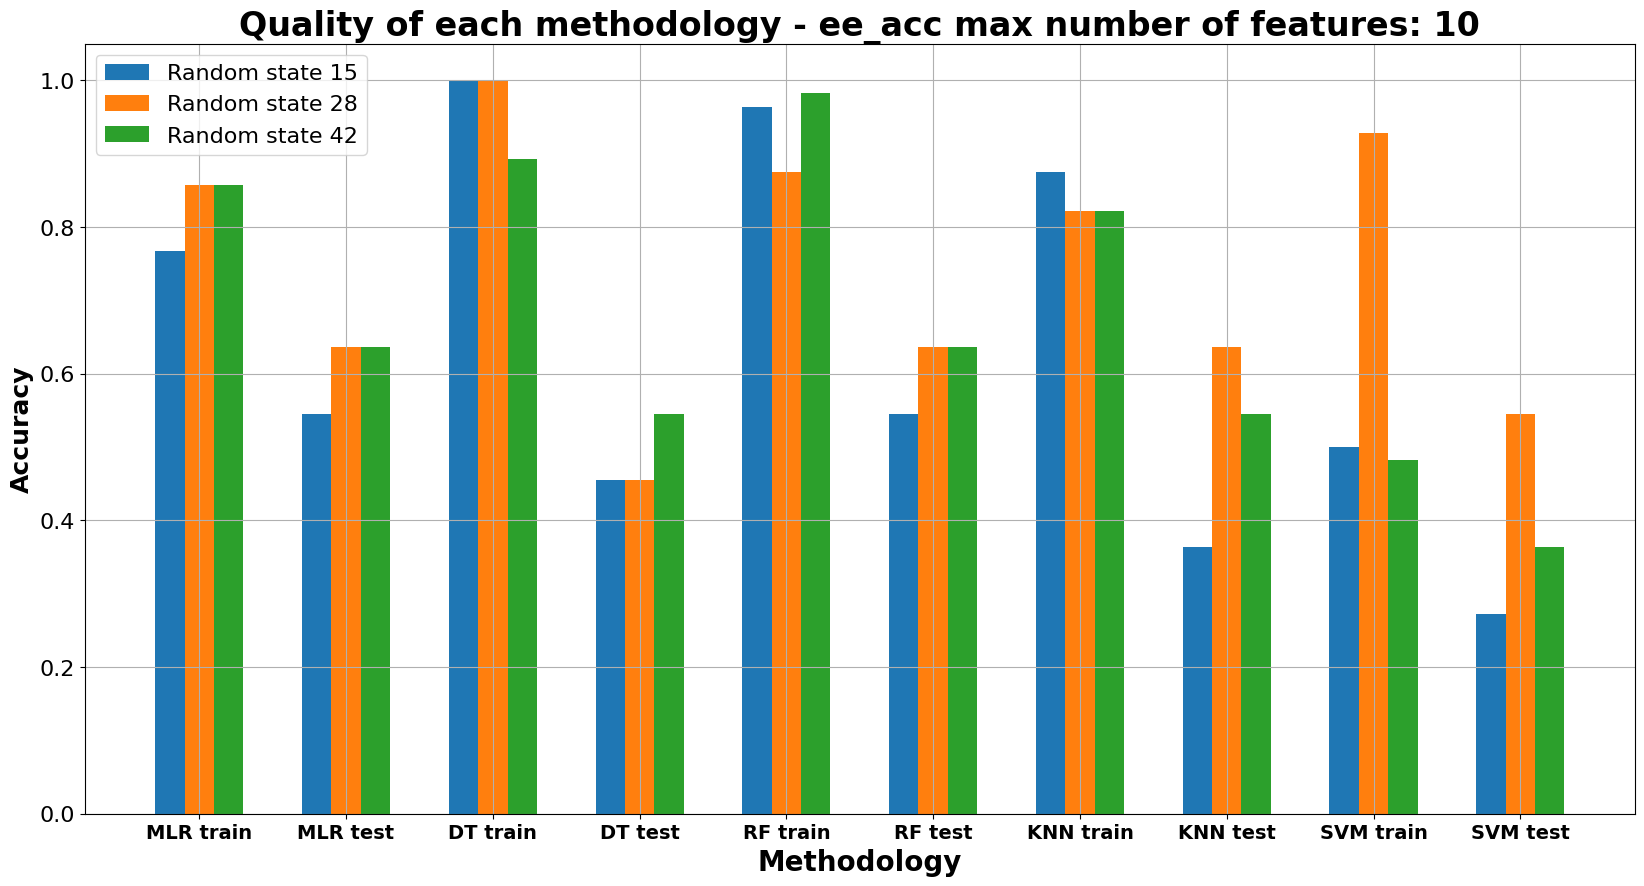

Random state - 15 ('MLR - number of features used: 5.0', 'DT - number of features used: 9.0', 'RF - number of features used: 8.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 28 ('MLR - number of features used: 8.0', 'DT - number of features used: 3.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 8.0')
Random state - 42 ('MLR - number of features used: 9.0', 'DT - number of features used: 8.0', 'RF - number of features used: 5.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')


C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_15.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_15.append(float(features))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_28.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_28.append(float(features)

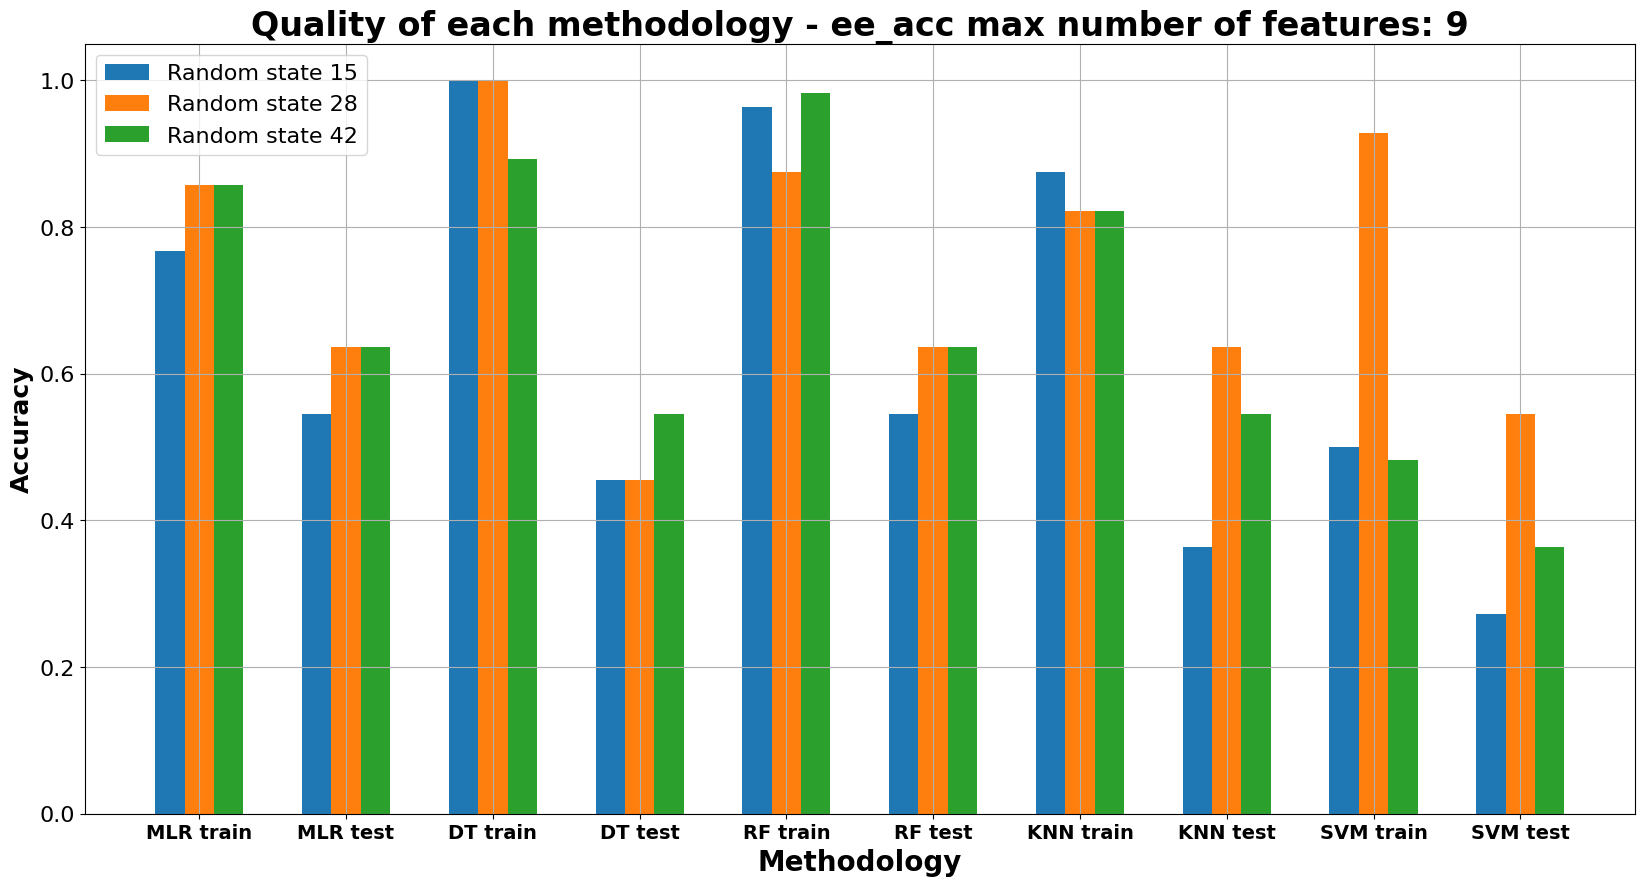

Random state - 15 ('MLR - number of features used: 5.0', 'DT - number of features used: 9.0', 'RF - number of features used: 8.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 28 ('MLR - number of features used: 8.0', 'DT - number of features used: 3.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 8.0')
Random state - 42 ('MLR - number of features used: 9.0', 'DT - number of features used: 8.0', 'RF - number of features used: 5.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')


C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_15.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_15.append(float(features))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_28.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_28.append(float(features)

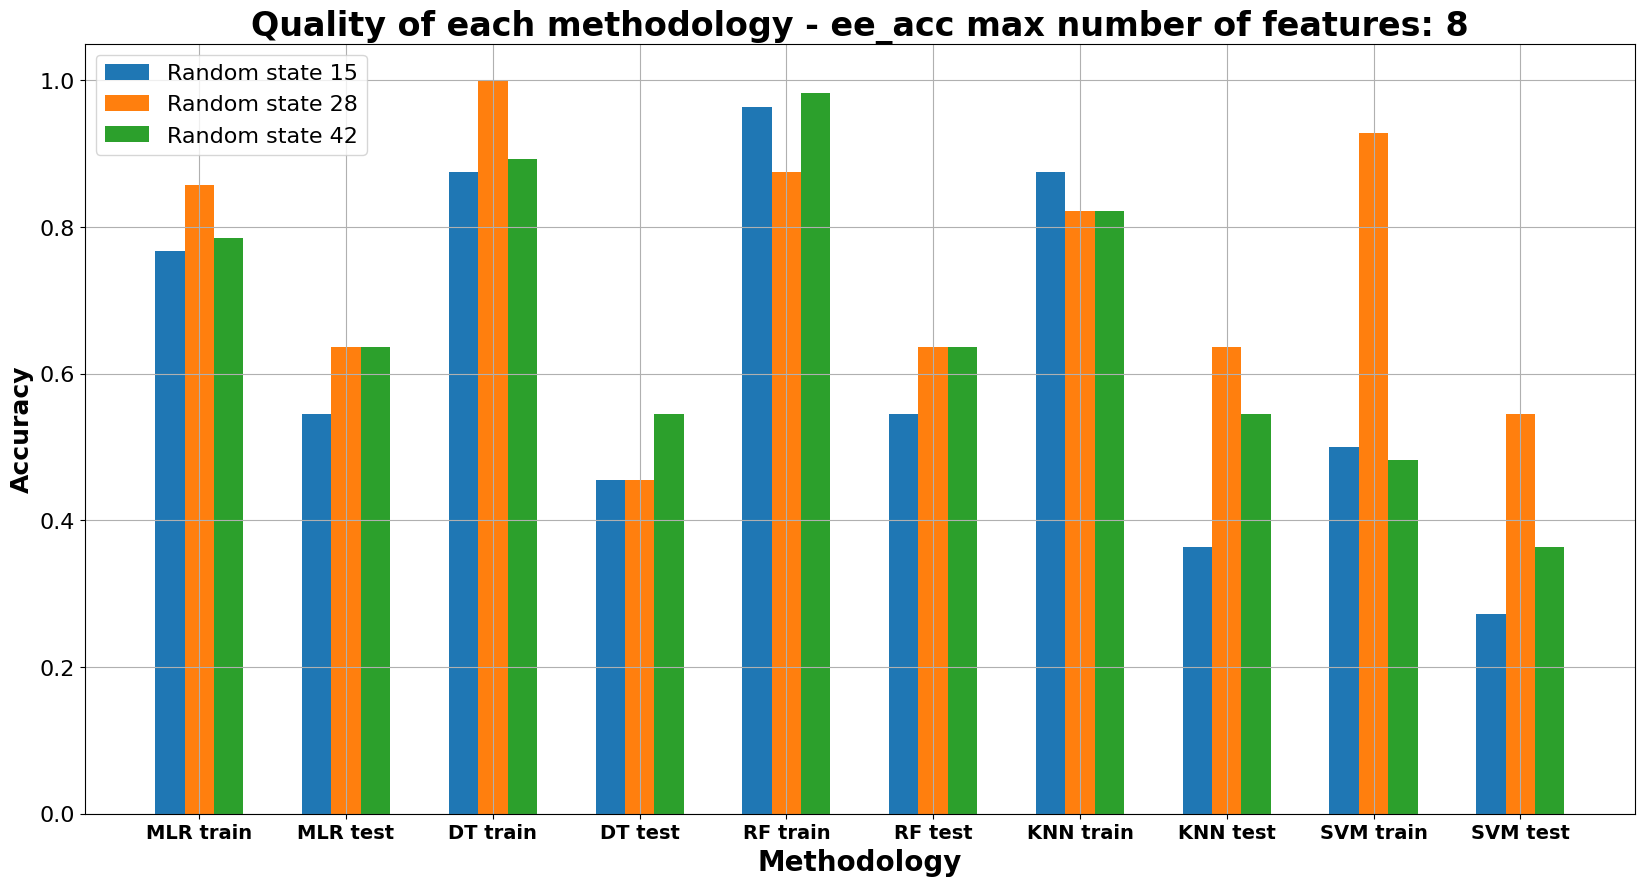

Random state - 15 ('MLR - number of features used: 5.0', 'DT - number of features used: 5.0', 'RF - number of features used: 8.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 28 ('MLR - number of features used: 8.0', 'DT - number of features used: 3.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 8.0')
Random state - 42 ('MLR - number of features used: 1.0', 'DT - number of features used: 8.0', 'RF - number of features used: 5.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')


C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_15.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_15.append(float(features))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_28.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_28.append(float(features)

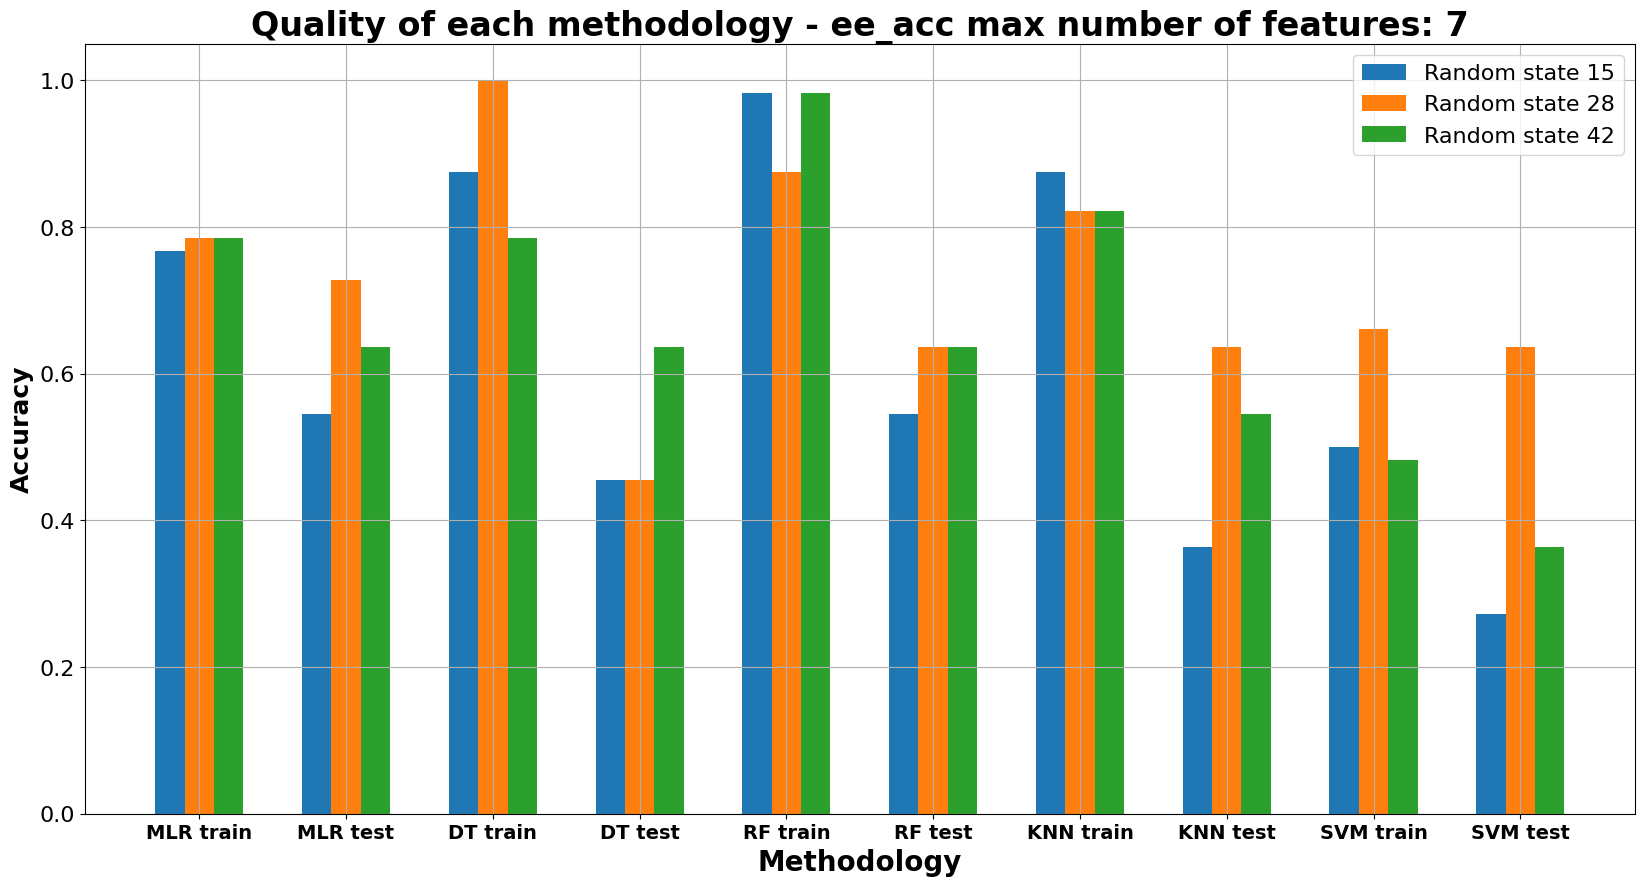

Random state - 15 ('MLR - number of features used: 5.0', 'DT - number of features used: 5.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 28 ('MLR - number of features used: 3.0', 'DT - number of features used: 3.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 42 ('MLR - number of features used: 1.0', 'DT - number of features used: 1.0', 'RF - number of features used: 5.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')


C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_15.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_15.append(float(features))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_28.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_28.append(float(features)

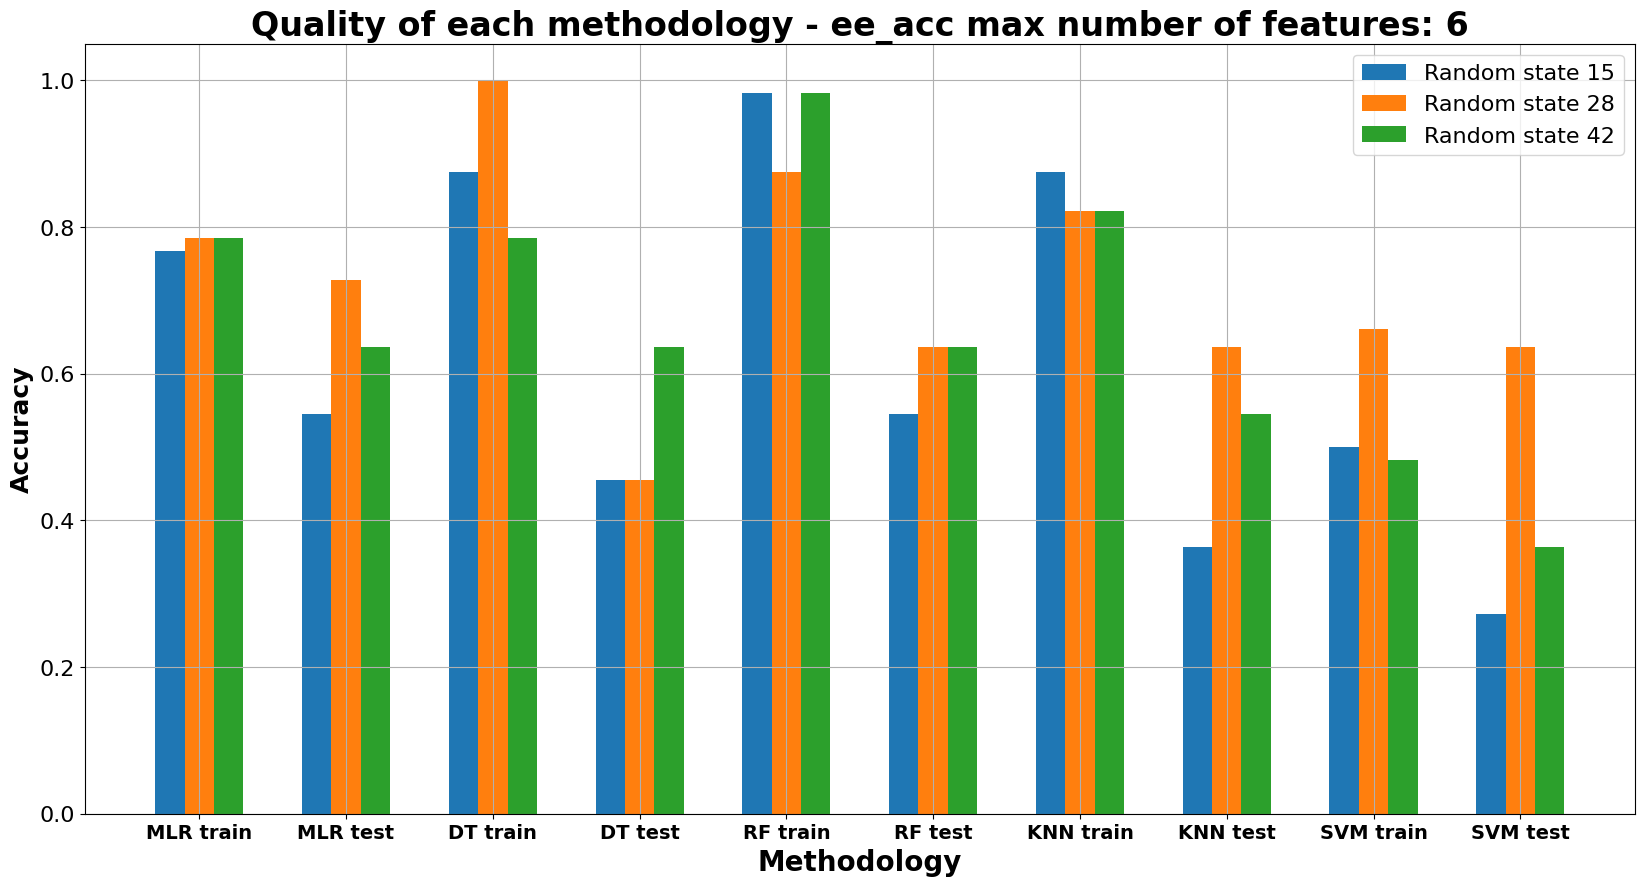

Random state - 15 ('MLR - number of features used: 5.0', 'DT - number of features used: 5.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 28 ('MLR - number of features used: 3.0', 'DT - number of features used: 3.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 42 ('MLR - number of features used: 1.0', 'DT - number of features used: 1.0', 'RF - number of features used: 5.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')


C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_15.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_15.append(float(features))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_28.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_28.append(float(features)

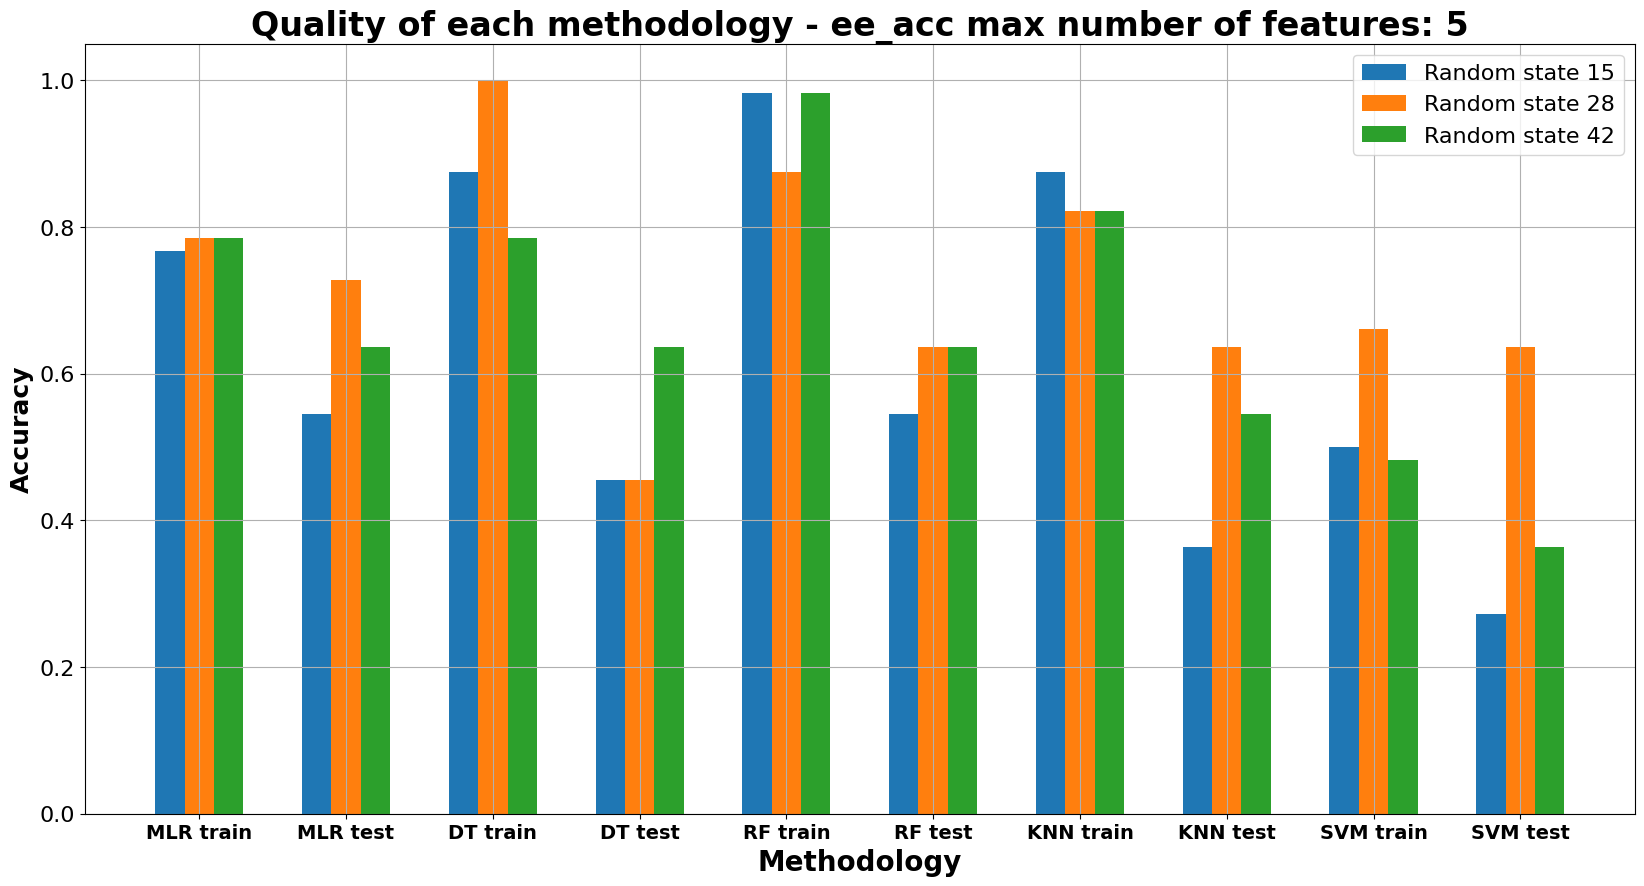

Random state - 15 ('MLR - number of features used: 5.0', 'DT - number of features used: 5.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 28 ('MLR - number of features used: 3.0', 'DT - number of features used: 3.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 42 ('MLR - number of features used: 1.0', 'DT - number of features used: 1.0', 'RF - number of features used: 5.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')


C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_15.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_15.append(float(features))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_28.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_28.append(float(features)

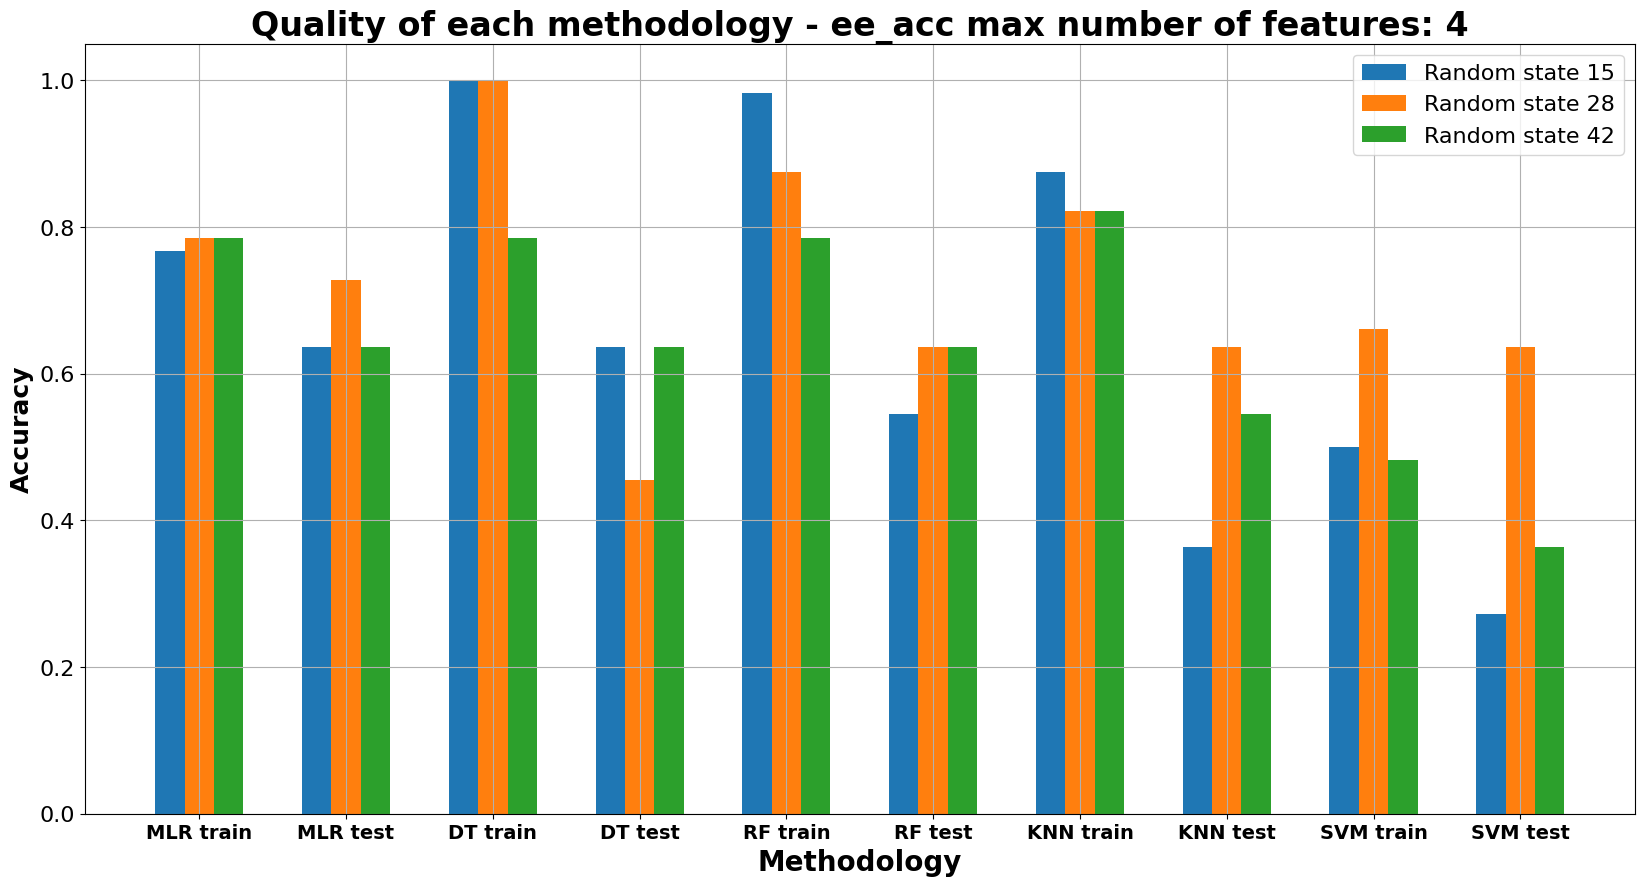

Random state - 15 ('MLR - number of features used: 3.0', 'DT - number of features used: 3.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 28 ('MLR - number of features used: 3.0', 'DT - number of features used: 3.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 42 ('MLR - number of features used: 1.0', 'DT - number of features used: 1.0', 'RF - number of features used: 1.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')


C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_15.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_15.append(float(features))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_28.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_28.append(float(features)

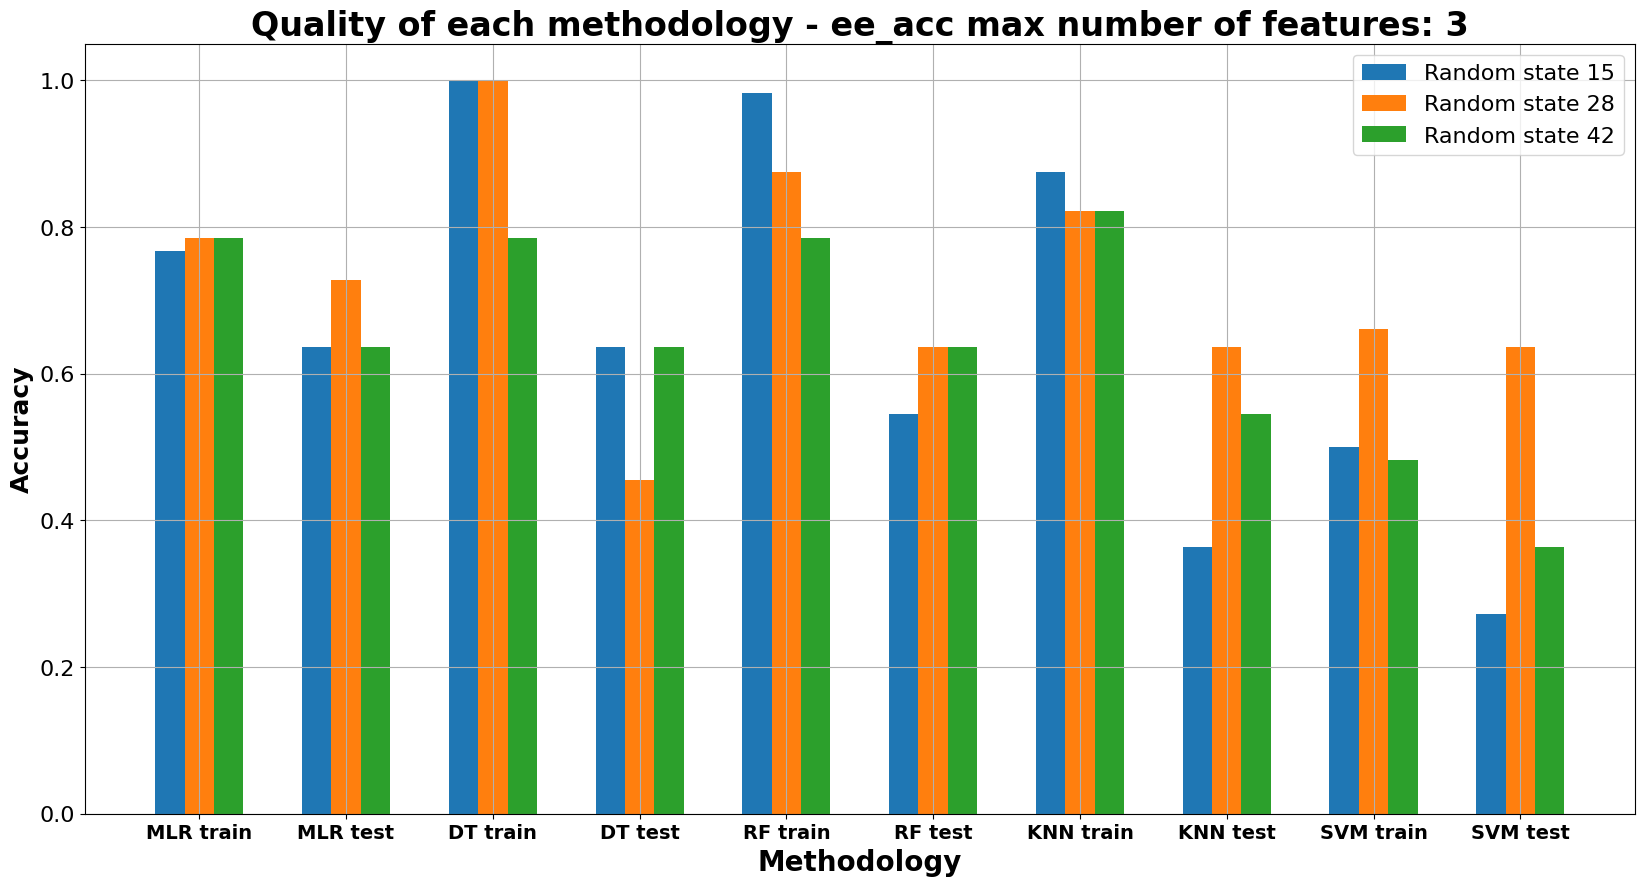

Random state - 15 ('MLR - number of features used: 3.0', 'DT - number of features used: 3.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 28 ('MLR - number of features used: 3.0', 'DT - number of features used: 3.0', 'RF - number of features used: 3.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')
Random state - 42 ('MLR - number of features used: 1.0', 'DT - number of features used: 1.0', 'RF - number of features used: 1.0', 'KNN - number of features used: 3.0', 'SVM - number of features used: 3.0')


C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_15.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_15.append(float(features))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  random_state_28.append(float(element))
C:\Users\aleks\AppData\Local\Temp\ipykernel_12300\3284106496.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  features_28.append(float(features)

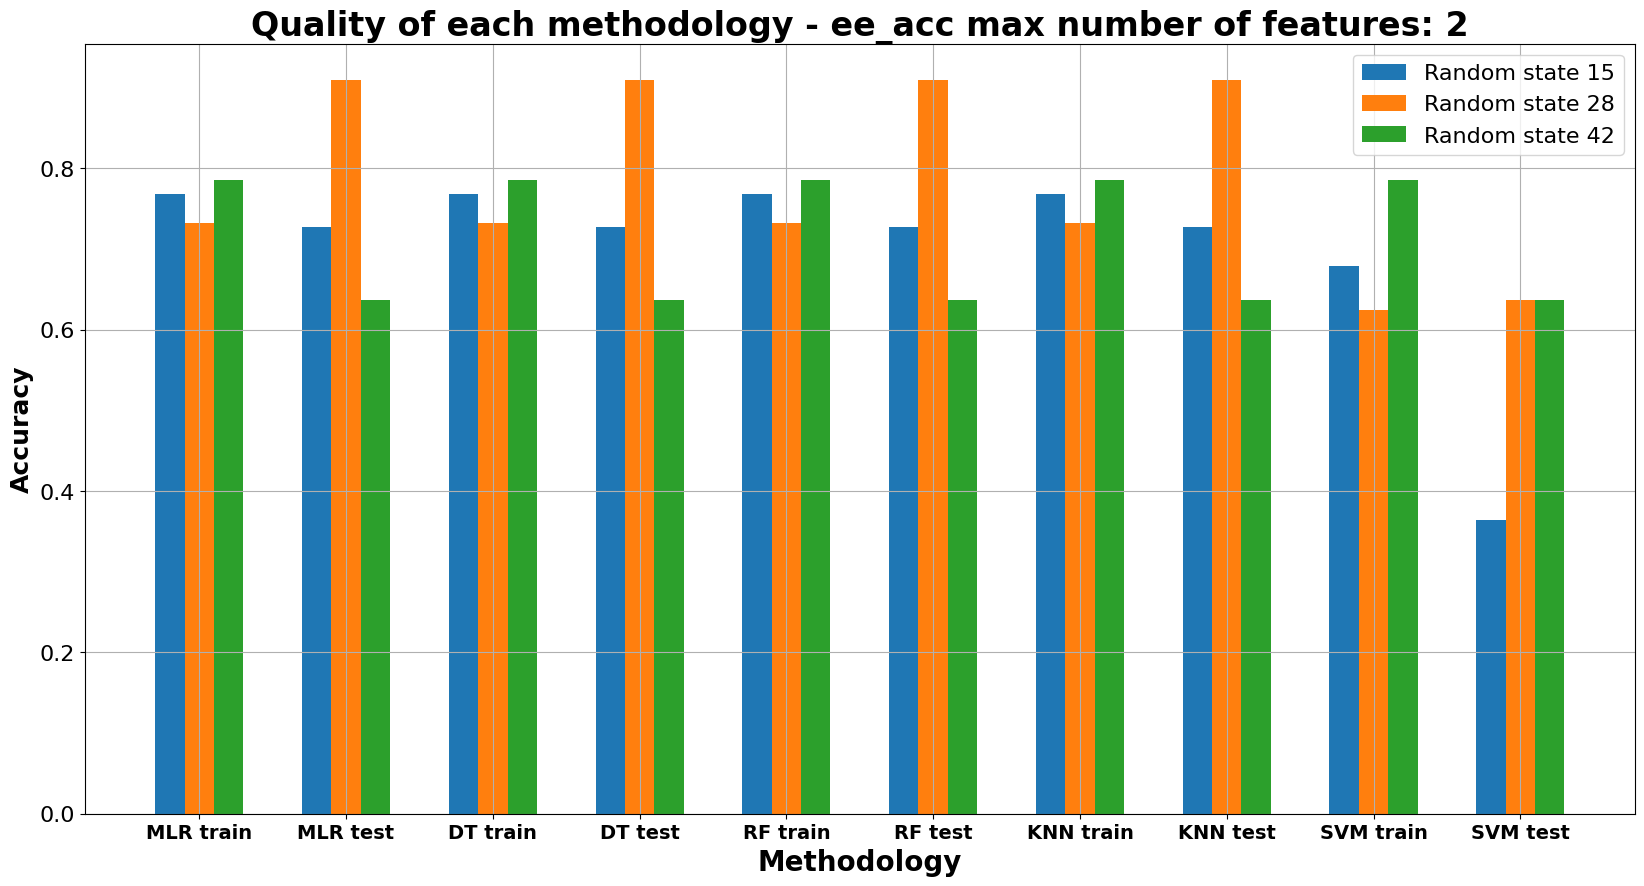

Random state - 15 ('MLR - number of features used: 1.0', 'DT - number of features used: 1.0', 'RF - number of features used: 1.0', 'KNN - number of features used: 1.0', 'SVM - number of features used: 1.0')
Random state - 28 ('MLR - number of features used: 1.0', 'DT - number of features used: 1.0', 'RF - number of features used: 1.0', 'KNN - number of features used: 1.0', 'SVM - number of features used: 1.0')
Random state - 42 ('MLR - number of features used: 1.0', 'DT - number of features used: 1.0', 'RF - number of features used: 1.0', 'KNN - number of features used: 1.0', 'SVM - number of features used: 1.0')


In [9]:
for i in range(12, 1, -1):
    ee = prepare_histogram_data('epox_cla', i)
    prepare_plot(ee, 'ee_acc', i)